<a href="https://colab.research.google.com/github/PrarthanaShende/AI-Projects-/blob/main/Mobile_Price_Prediciton_model_using_ANN_using_BatchNormalization_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mobile_Price_Prediciton_model_using_ANN_using_BatchNormalization
## Data Gathering

In [1]:
import pandas as pd
path= r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/mobile_train%20(1).csv"
df=pd.read_csv(path)
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



## Perform basic data quality checks

In [2]:
df.shape

(2000, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [4]:
df.duplicated().sum()

np.int64(0)

## Separate X and Y features

In [5]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [6]:
df['price_range'].unique()

array([1, 2, 3, 0])

Mobile Price Range:

0 : cheap 1: moderate 2: Mid range 3: Expensive

In [7]:
X=df.drop(columns='price_range')
Y=df[['price_range']]

In [8]:
X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [9]:
Y.head()

,price_range
0,1
1,2
2,2
3,2
4,1


## Feature Engg : Data Preprocessing - Data Cleaning and Data Scaling

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pre = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
).set_output(transform='pandas')

In [11]:
X_pre =pre.fit_transform(X)
X_pre.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099



## Split the data into training and testing

In [12]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest =train_test_split(X_pre,Y,train_size=0.75,random_state=42)


Multiclass classification : Y feature has multi classes ranging from 0-3. You must do encoding of Y feature before training the model so that it gets all the class labels for learning and predictions
You have to do onehot coding for Y feature

in this project, we have 4 classes to be predicted. y : [1] y: [0]

y : [0,0,0,1] y: [1,0,0,0]

In [13]:
Y.head(10)

,price_range
0,1
1,2
2,2
3,2
4,1
5,1
6,3
7,0
8,0
9,0


In [14]:
from keras.utils import to_categorical
ytrain_cat = to_categorical(ytrain)
ytest_cat =to_categorical(ytest)

In [15]:
ytrain_cat[:10]

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]])

## Model Building

In [16]:
from keras.models import Sequential
from keras.layers import Input, Dense, BatchNormalization
from keras.callbacks import EarlyStopping


In [17]:
ytrain_cat.shape

(1500, 4)

In [19]:
# Intialize the model
model= Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer 1
model.add(Dense(units=32,activation='relu'))

# Add the Dropout layer
model.add(BatchNormalization())

# Add the Hidden layer2
model.add(Dense(units=16,activation='relu'))

# Add the Dropout layer
model.add(BatchNormalization())

# Add the Output layer
model.add(Dense(units=ytrain_cat.shape[1],activation='softmax'))

In [20]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es =EarlyStopping(monitor='val_loss',patience=10)

In [21]:
nn=model.fit(xtrain,ytrain_cat,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.2833 - loss: 1.7101 - val_accuracy: 0.3100 - val_loss: 1.3955
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3375 - loss: 1.4323 - val_accuracy: 0.3533 - val_loss: 1.3080
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4142 - loss: 1.2623 - val_accuracy: 0.4333 - val_loss: 1.2242
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4808 - loss: 1.1299 - val_accuracy: 0.4967 - val_loss: 1.1312
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5525 - loss: 1.0072 - val_accuracy: 0.5633 - val_loss: 1.0332
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6025 - loss: 0.9128 - val_accuracy: 0.6200 - val_loss: 0.9407
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6500 - loss: 0.8370 - val_accuracy: 0.6333 - val_loss: 0.8631
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6875 - loss: 0.7531 - val_accuracy: 0.6800 - 


## Learning Curve

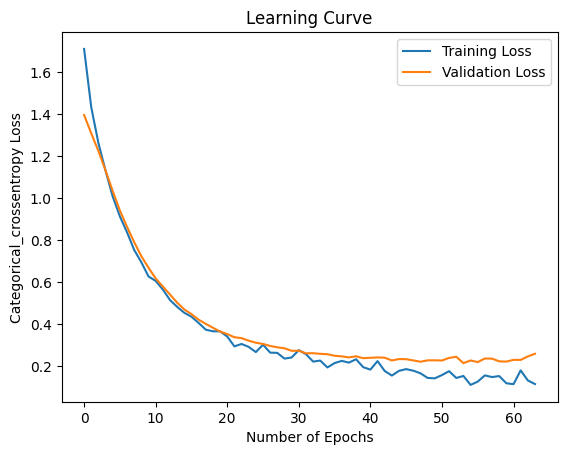

In [22]:

import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Categorical_crossentropy Loss")
plt.legend()
plt.show()

## Model evaluation

In [23]:
model.evaluate(xtrain,ytrain_cat)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9780 - loss: 0.0848


[0.08476336300373077, 0.9779999852180481]

In [24]:
model.evaluate(xtest,ytest_cat)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8740 - loss: 0.3000


[0.3000330328941345, 0.8740000128746033]

## Confusion matrix and Classification report

In [25]:
yprobs= model.predict(xtest)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [26]:
yprobs[:5]

array([[9.1222990e-01, 8.7764271e-02, 5.5353044e-06, 2.5441983e-07],
       [2.1117207e-04, 2.0480129e-01, 7.5546610e-01, 3.9521448e-02],
       [3.0143213e-02, 9.6565163e-01, 4.1969419e-03, 8.1251319e-06],
       [1.1332769e-04, 7.7774700e-08, 4.9035368e-03, 9.9498296e-01],
       [8.2666543e-04, 9.3452454e-01, 6.4613178e-02, 3.5699071e-05]],
      dtype=float32)

In [27]:
yprobs[0]

array([9.1222990e-01, 8.7764271e-02, 5.5353044e-06, 2.5441983e-07],
      dtype=float32)

In [28]:
import numpy as np
np.argmax(yprobs[0])  # give me the position of max value in yprobs[0] array

np.int64(0)

In [29]:
ypreds =[]
for i in yprobs:
  pos=np.argmax(i)
  ypreds.append(pos)
ypreds

[np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(3),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.in

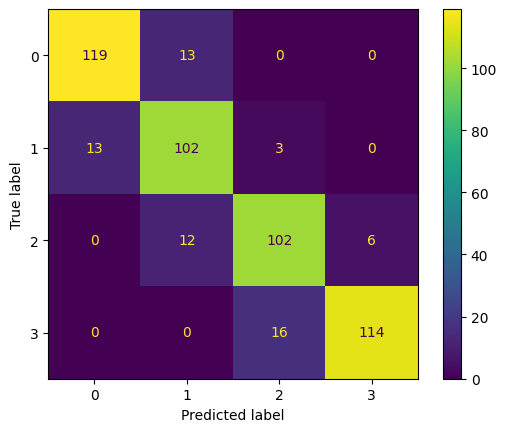

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
ConfusionMatrixDisplay.from_predictions(ytest,ypreds)


In [31]:
print(classification_report(ytest,ypreds))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       132
           1       0.80      0.86      0.83       118
           2       0.84      0.85      0.85       120
           3       0.95      0.88      0.91       130

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.88      0.87      0.87       500



Model is providing an accuracy of 90% in testing. We can consider this model for final predictions

In [32]:
model.save("MobilePredictions2.keras")

In [33]:
from keras.models import load_model
m1=load_model('/content/MobilePredictions2.keras')
m1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,190 (16.37 KB)

 Trainable params: 1,364 (5.33 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 2,730 (10.67 KB)